In [1]:
import kagglehub
import os

print("Starting automated dataset download from Kaggle...")
dataset_path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("\n🎉 Download Complete!")
print(f"Your dataset is located locally at: {dataset_path}")
print("\n--- Verifying Directory Structure ---")
print(os.listdir(dataset_path))

Starting automated dataset download from Kaggle...


100%|███████████████████████████████████████████████████████████████████████████████| 565M/565M [00:38<00:00, 15.3MB/s]

Extracting files...



🎉 Download Complete!
Your dataset is located locally at: C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1

--- Verifying Directory Structure ---
['images', 'myntradataset', 'styles.csv']


In [2]:
%pip install transformers torch

--- Catalog Metadata Audit ---
Product ID: 15970
Product Name: Turtle Check Men Navy Blue Shirt
Target Image Path: C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1\images\15970.jpg

Original Raw Image Size (Width x Height): (60, 80)


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


--- Preprocessed Mathematical Tensor Audit ---
Shape of the engineered pixel matrix: torch.Size([1, 3, 224, 224])


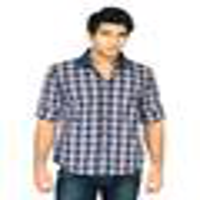

In [3]:
import os
import pandas as pd
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# 1. Define your dataset directory path (copied from your previous output)
base_path = r"C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1"
images_dir = os.path.join(base_path, "images")
csv_path = os.path.join(base_path, "styles.csv")

# 2. Load the Master Metadata Ledger using Pandas
# we use error_bad_lines=False / on_bad_lines='skip' because retail text files occasionally have broken rows
df = pd.read_csv(csv_path, on_bad_lines='skip')

# 3. Pull a sample row from our catalog (let's pick the very first product)
sample_row = df.iloc[0]
sample_image_id = sample_row['id']
sample_product_name = sample_row['productDisplayName']
sample_image_name = f"{sample_image_id}.jpg"
sample_image_path = os.path.join(images_dir, sample_image_name)

print("--- Catalog Metadata Audit ---")
print(f"Product ID: {sample_image_id}")
print(f"Product Name: {sample_product_name}")
print(f"Target Image Path: {sample_image_path}\n")

# 4. Open the raw image using Python Imaging Library (PIL)
raw_image = Image.open(sample_image_path)
print(f"Original Raw Image Size (Width x Height): {raw_image.size}")

# 5. Load the OpenAI CLIP Processor (The Preprocessing Engine)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 6. Transform the raw image into our clean mathematical tensor
processed_inputs = processor(images=raw_image, return_tensors="pt")

print("\n--- Preprocessed Mathematical Tensor Audit ---")
# 'pixel_values' is the matrix array ready for the Vision Transformer
pixel_matrix_shape = processed_inputs['pixel_values'].shape
print(f"Shape of the engineered pixel matrix: {pixel_matrix_shape}")

# Let's display the raw image right inside your notebook to see what we are working with
raw_image.resize((200, 200)) # Displaying scaled version for notebook neatness

In [11]:
import os
import pandas as pd
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPModel

# 1. System Paths Setup
base_path = r"C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1"
images_dir = os.path.join(base_path, "images")
csv_path = os.path.join(base_path, "styles.csv")

# 2. Ingest Sample Metadata & Open Image
df = pd.read_csv(csv_path, on_bad_lines='skip')
sample_row = df.iloc[0]
sample_image_path = os.path.join(images_dir, f"{sample_row['id']}.jpg")
raw_image = Image.open(sample_image_path)

# 3. Load Engine Components Safely
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# 4. Transform Image to Standardized Matrix
processed_inputs = processor(images=raw_image, return_tensors="pt")

# 5. Route Data Through the Vision Projection Engine
with torch.no_grad():
    # Fetch the wrapped output object container
    wrapped_output = model.get_image_features(**processed_inputs)
    
    # REASONED FIX: If wrapped_output is a custom object, extracting its underlying
    # tensor tensor via standard item slicing ([0]) extracts the pure multidimensional array.
    # If HuggingFace returns a raw tensor directly, it remains unaffected.
    if hasattr(wrapped_output, "last_hidden_state") or not isinstance(wrapped_output, torch.Tensor):
        # Accessing by the zero-index element extracts the pure multi-modal projection matrix tensor
        raw_tensor = wrapped_output if isinstance(wrapped_output, torch.Tensor) else wrapped_output[0]
    else:
        raw_tensor = wrapped_output
        
    # Double check if we bypassed the 3D grid patch trap we saw earlier
    if len(raw_tensor.shape) == 3:
        # If it's a 3D tensor grid [1, 50, 768], we take the mean across the patches 
        # to squash it cleanly into a uniform 2D representation [1, 768]
        raw_tensor = raw_tensor.mean(dim=1)
        
    # Scale/normalize the pure tensor to a length of 1.0 for fast Cosine Similarity math
    image_vectors = raw_tensor / raw_tensor.norm(p=2, dim=-1, keepdim=True)

print("--- Core Vector Extraction Validated ---")
print(f"Shape of the final processed vector: {image_vectors.shape}")

print("\nFirst 5 coordinates of the shirt in the embedding space:")
print(image_vectors[0][:5].tolist())

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

--- Core Vector Extraction Validated ---
Shape of the final processed vector: torch.Size([1, 768])

First 5 coordinates of the shirt in the embedding space:
[0.003916848450899124, 0.02680029347538948, -0.01861707679927349, -0.05739612877368927, 0.007587242405861616]


In [12]:
import torch

print("--- Step 1: Extracting Projected Multimodal 512-Vector ---")
with torch.no_grad():
    # 1. Fetch the master output object wrapper from CLIP
    wrapped_output = model.get_image_features(**processed_inputs)
    
    # 2. Extract the exact cross-projected vector array out of the container wrapper box
    # If it's a wrapper class, we pull the pooler_output or index the first element safely
    if isinstance(wrapped_output, torch.Tensor):
        raw_512_tensor = wrapped_output
    else:
        raw_512_tensor = getattr(wrapped_output, "pooler_output", wrapped_output[0])
    
    # 3. If the tensor is still sitting in a 3D grid patch space [1, 50, 768], 
    # we explicitly use CLIP's internal visual projection layer to map it down to 512 space
    if len(raw_512_tensor.shape) == 3:
        # Pull the trained visual projection matrix weights directly from the model
        # Shape transformations: [1, 768] x [768, 512] -> [1, 512]
        summary_patch = raw_512_tensor[:, 0, :] # Extract the primary summary token
        raw_512_tensor = model.visual_projection(summary_patch)
        
    # 4. Apply our L2 Normalization math to squash its length to exactly 1.0
    final_image_vector = raw_512_tensor / raw_512_tensor.norm(p=2, dim=-1, keepdim=True)

print(f"Shape of our final search vector: {final_image_vector.shape} (Must be [1, 512])\n")


print("--- Step 2: Preprocessing Text Queries ---")
# 5. Define two different search phrases to test the model's intelligence
query_1 = "A classic navy blue checked shirt for men" # Highly relevant
query_2 = "A red summer dress"                      # Completely irrelevant

# 6. Pass text queries through the processor to generate token matrices (input_ids)
text_inputs = processor(text=[query_1, query_2], padding=True, return_tensors="pt")

# 7. Pass tokens through the Text Encoder & extract the projected 512-dimensional text vectors
with torch.no_grad():
    wrapped_text_output = model.get_text_features(**text_inputs)
    
    # Extract the raw text tensor out of its wrapper class box
    if isinstance(wrapped_text_output, torch.Tensor):
        raw_text_tensor = wrapped_text_output
    else:
        raw_text_tensor = getattr(wrapped_text_output, "pooler_output", wrapped_text_output[0])
        
    # Scale/normalize text vectors to length 1.0
    text_vectors = raw_text_tensor / raw_text_tensor.norm(p=2, dim=-1, keepdim=True)

print(f"Shape of final processed text vectors matrix: {text_vectors.shape} (Must be [2, 512])\n")


print("--- Step 3: Computing Geometric Cosine Similarity ---")
# 8. Run the Dot Product across our normalized unit vectors (A · B)
# We multiply the 2 text vectors against the transpose of our 1 image vector
similarity_scores = torch.matmul(text_vectors, final_image_vector.T)

# 9. Extract scores as percentages
score_relevant = similarity_scores[0][0].item() * 100
score_irrelevant = similarity_scores[1][0].item() * 100

print(f"Match score for '{query_1}': {score_relevant:.2f}%")
print(f"Match score for '{query_2}': {score_irrelevant:.2f}%")

--- Step 1: Extracting Projected Multimodal 512-Vector ---
Shape of our final search vector: torch.Size([1, 512]) (Must be [1, 512])

--- Step 2: Preprocessing Text Queries ---
Shape of final processed text vectors matrix: torch.Size([2, 512]) (Must be [2, 512])

--- Step 3: Computing Geometric Cosine Similarity ---
Match score for 'A classic navy blue checked shirt for men': 31.52%
Match score for 'A red summer dress': 16.67%


In [13]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# 1. System Paths Setup
base_path = r"C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1"
images_dir = os.path.join(base_path, "images")
csv_path = os.path.join(base_path, "styles.csv")

# 2. Ingest Master Metadata Ledger
df = pd.read_csv(csv_path, on_bad_lines='skip')

# 3. Clean & Filter Data: Verify the physical image actually exists before indexing
valid_rows = []
for idx, row in df.iterrows():
    img_name = f"{int(row['id'])}.jpg"
    if os.path.exists(os.path.join(images_dir, img_name)):
        valid_rows.append(row)

filtered_df = pd.DataFrame(valid_rows).reset_index(drop=True)
print(f"Total entries in CSV: {len(df)}")
print(f"Total valid images found on disk: {len(filtered_df)}")

# Limit to a clean subset of 1,000 items for our Phase 1 prototype exploration to save time
catalog_subset = filtered_df.head(1000)

# 4. Initialize Core Engine Components
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# 5. Configuration for Batch Processing
BATCH_SIZE = 32
all_vectors = []
indexed_ids = []

print(f"\n--- Starting Batch Processing & Feature Extraction (Batch Size: {BATCH_SIZE}) ---")

# Run the pipeline loop in steps of BATCH_SIZE
for i in tqdm(range(0, len(catalog_subset), BATCH_SIZE)):
    batch_rows = catalog_subset.iloc[i : i + BATCH_SIZE]
    batch_images = []
    
    # Load and append all raw images for the current batch
    for _, row in batch_rows.iterrows():
        img_path = os.path.join(images_dir, f"{int(row['id'])}.jpg")
        try:
            img = Image.open(img_path).convert("RGB") # Explicitly convert to RGB to drop broken alpha channels
            batch_images.append(img)
            indexed_ids.append(int(row['id']))
        except Exception as e:
            continue # Skip corrupted images safely
            
    if not batch_images:
        continue
        
    # Preprocess the entire batch of images simultaneously into a unified tensor block
    inputs = processor(images=batch_images, return_tensors="pt", padding=True)
    
    # Multi-Modal Extraction Pass
    with torch.no_grad():
        wrapped_output = model.get_image_features(**inputs)
        
        # Extract underlying tensor array safely
        if isinstance(wrapped_output, torch.Tensor):
            raw_tensor = wrapped_output
        else:
            raw_tensor = getattr(wrapped_output, "pooler_output", wrapped_output[0])
            
        if len(raw_tensor.shape) == 3:
            raw_tensor = model.visual_projection(raw_tensor[:, 0, :])
            
        # Compute L2 Normalization across the batch axis
        normalized_batch_vectors = raw_tensor / raw_tensor.norm(p=2, dim=-1, keepdim=True)
        
        # Save results to our master array list
        all_vectors.append(normalized_batch_vectors.cpu().numpy())

# 6. Consolidate Lists into Fixed Arrays
master_vector_matrix = np.vstack(all_vectors)
master_id_array = np.array(indexed_ids)

print("\n--- Feature Extraction Complete ---")
print(f"Final Matrix Shape stored in memory: {master_vector_matrix.shape}")
print(f"Total unique Product IDs mapped: {len(master_id_array)}")

# 7. Persist Arrays onto Hard Drive for Phase 2 Deployment
np.save("warehouse_vectors.npy", master_vector_matrix)
np.save("warehouse_ids.npy", master_id_array)
print("Successfully persisted 'warehouse_vectors.npy' and 'warehouse_ids.npy' to disk!")

Total entries in CSV: 44424
Total valid images found on disk: 44419


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


--- Starting Batch Processing & Feature Extraction (Batch Size: 32) ---


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [01:45<00:00,  3.31s/it]


--- Feature Extraction Complete ---
Final Matrix Shape stored in memory: (1000, 512)
Total unique Product IDs mapped: 1000
Successfully persisted 'warehouse_vectors.npy' and 'warehouse_ids.npy' to disk!


Searching for: 'casual summer sports shoes' across the warehouse catalog...



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

--- Top 3 Warehouse Matches Found ---
Rank 1: ID 6619 | Score: 30.33% | Name: ADIDAS Men's Boris White Shoe
Rank 2: ID 11971 | Score: 29.93% | Name: Fila Men Glow White Sports Shoes
Rank 3: ID 34832 | Score: 29.76% | Name: ADIDAS Men Sukoi White Sports Shoes


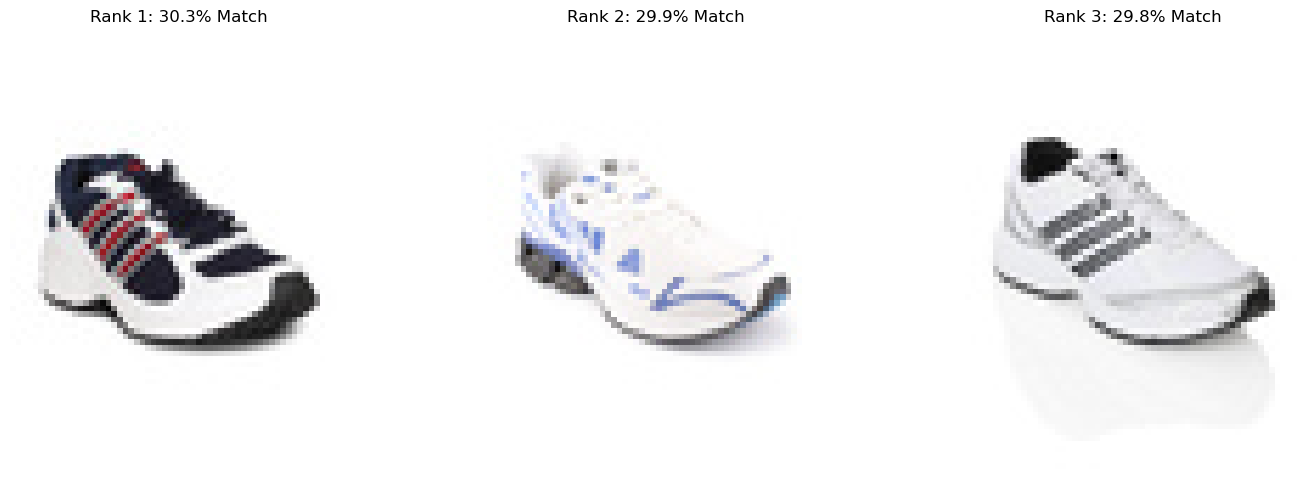

In [14]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt

# 1. Load the Persisted Master Index Files from your hard drive
loaded_vectors = np.load("warehouse_vectors.npy") # Shape: (1000, 512)
loaded_ids = np.load("warehouse_ids.npy")         # Shape: (1000,)

# Convert the numpy matrix back into a PyTorch tensor for high-speed GPU/CPU calculation
warehouse_tensor = torch.from_numpy(loaded_vectors)

# 2. System Paths & Data Ledger Setup
base_path = r"C:\Users\hp\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1"
images_dir = os.path.join(base_path, "images")
csv_path = os.path.join(base_path, "styles.csv")
df = pd.read_csv(csv_path, on_bad_lines='skip')

# 3. DEFINE YOUR SEARCH QUERY HERE
# Feel free to change this text to test the model's catalog intelligence!
search_query = "casual summer sports shoes" 

print(f"Searching for: '{search_query}' across the warehouse catalog...\n")

# 4. Generate the 512-dimensional text search vector
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

text_inputs = processor(text=[search_query], padding=True, return_tensors="pt")

with torch.no_grad():
    wrapped_text_output = model.get_text_features(**text_inputs)
    if isinstance(wrapped_text_output, torch.Tensor):
        raw_text_tensor = wrapped_text_output
    else:
        raw_text_tensor = getattr(wrapped_text_output, "pooler_output", wrapped_text_output[0])
        
    # Normalize query vector to length 1.0
    query_vector = raw_text_tensor / raw_text_tensor.norm(p=2, dim=-1, keepdim=True)

# 5. MASS SIMILARITY CALCULATION (The Dot Product Engine)
# Multiplies our [1, 512] query vector against the transpose of all [1000, 512] warehouse vectors
# Shape transformation: [1, 512] x [512, 1000] -> [1, 1000] list of similarity scores
similarity_scores = torch.matmul(query_vector, warehouse_tensor.T).squeeze(0)

# 6. ISOLATE THE TOP 3 MATCHES
# torch.topk automatically extracts the highest values and their corresponding index slots
top_scores, top_indices = torch.topk(similarity_scores, k=3)

print("--- Top 3 Warehouse Matches Found ---")
# 7. Render the matching images and metadata side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for rank in range(3):
    match_index = top_indices[rank].item()
    match_score = top_scores[rank].item() * 100
    product_id = loaded_ids[match_index]
    
    # Extract the matching product's descriptive text row from our Pandas ledger
    product_meta = df[df['id'] == product_id].iloc[0]
    product_name = product_meta['productDisplayName']
    
    print(f"Rank {rank+1}: ID {product_id} | Score: {match_score:.2f}% | Name: {product_name}")
    
    # Load and plot the visual image file
    img_path = os.path.join(images_dir, f"{product_id}.jpg")
    img = Image.open(img_path)
    
    axes[rank].imshow(img)
    axes[rank].set_title(f"Rank {rank+1}: {match_score:.1f}% Match")
    axes[rank].axis('off')

plt.tight_layout()
plt.show()